# S4 Ablation Study — EEG-only / sEMG-only / EEG+sEMG Fusion

**실행 순서**
1. **셀 1**: ablation_study.py 내장 스크립트 기록
2. **셀 2**: Drive 마운트 & 패키지 설치
3. **셀 2b**: HDF5 데이터 로컬 복사 (Drive 끊김 방지, ~5~10분)
4. **셀 3**: EEG-only LOSO (약 2~3시간)
5. **셀 4**: sEMG-only LOSO (약 1~2시간)
6. **셀 5**: Fusion 평가 (기존 체크포인트, 약 10분)
7. **셀 6**: 세 조건 병합 & 요약 출력
8. **셀 7**: 시각화

In [2]:
%%writefile /content/ablation_study.py
"""
ablation_study.py — EEG-only / sEMG-only / Fusion LOSO 52-fold Ablation
=========================================================================
Colab 실행:
  !python ablation_study.py --model_type eeg_only  --drive_root /content/drive/MyDrive/BCI_Research
  !python ablation_study.py --model_type emg_only  --drive_root /content/drive/MyDrive/BCI_Research
  !python ablation_study.py --model_type fusion     --drive_root /content/drive/MyDrive/BCI_Research

로컬 실행 (PyTorch 환경):
  python src/ablation_study.py --model_type fusion --data_dir BCI_Research/preprocessed/member_A

출력:
  results/ablation/
  ├── ablation_eeg_only_results.csv
  ├── ablation_emg_only_results.csv
  ├── ablation_fusion_results.csv   ← 세 개 합산 후 ablation_results.csv 생성
  ├── ablation_results.csv          (all_conditions 병합)
  ├── ablation_summary.json
  └── ablation_confusion_matrix.json
"""

import os
import sys
import json
import time
import random
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                              confusion_matrix, classification_report,
                              f1_score)

# ── AMP 호환 헬퍼 (PyTorch 2.5+ 신 API / 구 API 자동 선택) ───────
def _amp_autocast(enabled: bool):
    try:
        return torch.amp.autocast(device_type="cuda", enabled=enabled)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=enabled)  # type: ignore[attr-defined]

def _amp_scaler():
    try:
        return torch.amp.GradScaler("cuda")
    except AttributeError:
        return torch.cuda.amp.GradScaler()  # type: ignore[attr-defined]

# ── 재현성 ──────────────────────────────────────────────────────
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

# ── ITR ─────────────────────────────────────────────────────────
def calc_itr(accuracy, n_classes=2, trial_duration_sec=4.5):
    p = np.clip(accuracy, 1e-9, 1 - 1e-9)
    if p >= 1.0 - 1e-9:
        B = np.log2(n_classes)
    else:
        B = (np.log2(n_classes)
             + p * np.log2(p)
             + (1 - p) * np.log2((1 - p) / (n_classes - 1)))
    return float(max(0.0, B) * (60.0 / trial_duration_sec))


# ════════════════════════════════════════════════════════════════
#  Dataset
# ════════════════════════════════════════════════════════════════

class BCIDataset(Dataset):
    def __init__(self, h5_path: str, emg_ds_factor: int = 8):
        with h5py.File(h5_path, "r") as f:
            eeg = f["eeg/epochs"][:]          # (N, 64, 2304)
            lbl = f["labels"][:].astype(np.int64) - 1  # 1/2 → 0/1
            if "emg" in f and "epochs" in f["emg"]:
                emg = f["emg/epochs"][:]      # (N, 4, 2304)
            else:
                emg = np.zeros((eeg.shape[0], 4, eeg.shape[2]), dtype=np.float32)

        if emg_ds_factor > 1:
            emg = emg[:, :, ::emg_ds_factor]  # → (N, 4, 288)

        n = min(eeg.shape[0], emg.shape[0], lbl.shape[0])
        self.eeg = torch.tensor(eeg[:n], dtype=torch.float32)
        self.emg = torch.tensor(emg[:n], dtype=torch.float32)
        self.lbl = torch.tensor(lbl[:n], dtype=torch.long)

    def __len__(self):
        return len(self.lbl)

    def __getitem__(self, idx):
        return self.eeg[idx], self.emg[idx], self.lbl[idx]


# ════════════════════════════════════════════════════════════════
#  Model 정의
# ════════════════════════════════════════════════════════════════

CFG = {
    "n_eeg_ch": 64, "n_emg_ch": 4, "n_times": 2304,
    "n_classes": 2, "emg_ds_factor": 8,
    "eegnet_F1": 8, "eegnet_D": 2, "eegnet_kern_len": 256, "eegnet_dropout": 0.5,
    "lstm_hidden": 128, "lstm_layers": 2, "lstm_dropout": 0.3,
    "clf_dropout": 0.3, "feat_dim": 256,
}
CFG["n_times_emg"] = CFG["n_times"] // CFG["emg_ds_factor"]


class EEGNetEncoder(nn.Module):
    def __init__(self, n_ch=64, n_times=2304, F1=8, D=2,
                 kern_len=256, dropout=0.5, feat_dim=256):
        super().__init__()
        F2 = F1 * D
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_len), padding=(0, kern_len // 2), bias=False),
            nn.BatchNorm2d(F1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F2, (n_ch, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 4)), nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, 1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 8)), nn.Dropout(dropout),
        )
        with torch.no_grad():
            flat = self.block3(self.block2(
                self.block1(torch.zeros(1, 1, n_ch, n_times)))).numel()
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(flat, feat_dim), nn.ELU())

    def forward(self, x):
        return self.fc(self.block3(self.block2(self.block1(x.unsqueeze(1)))))


class EMGBiLSTMEncoder(nn.Module):
    def __init__(self, n_ch=4, hidden=128, n_layers=2,
                 dropout=0.3, feat_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(
            n_ch, hidden, n_layers, batch_first=True, bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc   = nn.Sequential(nn.Linear(hidden * 2, feat_dim), nn.ELU())

    def forward(self, x):
        out, _ = self.lstm(x.permute(0, 2, 1))
        return self.fc(self.norm(out[:, -1, :]))


class SoftmaxAttentionFusion(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        self.W_eeg = nn.Linear(feat_dim, feat_dim)
        self.W_emg = nn.Linear(feat_dim, feat_dim)
        self.attn  = nn.Linear(feat_dim * 2, 2)

    def forward(self, h_eeg, h_emg):
        w = F.softmax(self.attn(torch.cat([h_eeg, h_emg], dim=-1)), dim=-1)
        return w[:, 0:1] * self.W_eeg(h_eeg) + w[:, 1:2] * self.W_emg(h_emg), w


# ── 세 가지 모델 ─────────────────────────────────────────────────

class EEGOnlyModel(nn.Module):
    """EEG 스트림만 사용. EMG 입력을 받아도 무시."""
    def __init__(self, cfg):
        super().__init__()
        fd = cfg["feat_dim"]
        self.enc = EEGNetEncoder(
            cfg["n_eeg_ch"], cfg["n_times"],
            cfg["eegnet_F1"], cfg["eegnet_D"],
            cfg["eegnet_kern_len"], cfg["eegnet_dropout"], fd,
        )
        self.clf = nn.Sequential(
            nn.Linear(fd, 128), nn.ELU(),
            nn.Dropout(cfg["clf_dropout"]),
            nn.Linear(128, cfg["n_classes"]),
        )

    def forward(self, eeg, emg=None):
        return self.clf(self.enc(eeg)), None


class EMGOnlyModel(nn.Module):
    """sEMG 스트림만 사용. EEG 입력을 받아도 무시."""
    def __init__(self, cfg):
        super().__init__()
        fd = cfg["feat_dim"]
        self.enc = EMGBiLSTMEncoder(
            cfg["n_emg_ch"], cfg["lstm_hidden"],
            cfg["lstm_layers"], cfg["lstm_dropout"], fd,
        )
        self.clf = nn.Sequential(
            nn.Linear(fd, 128), nn.ELU(),
            nn.Dropout(cfg["clf_dropout"]),
            nn.Linear(128, cfg["n_classes"]),
        )

    def forward(self, eeg=None, emg=None):
        return self.clf(self.enc(emg)), None


class FusionModel(nn.Module):
    """EEG + sEMG Fusion (기존 HybridBCIModel)."""
    def __init__(self, cfg):
        super().__init__()
        fd = cfg["feat_dim"]
        self.eeg_enc = EEGNetEncoder(
            cfg["n_eeg_ch"], cfg["n_times"],
            cfg["eegnet_F1"], cfg["eegnet_D"],
            cfg["eegnet_kern_len"], cfg["eegnet_dropout"], fd,
        )
        self.emg_enc = EMGBiLSTMEncoder(
            cfg["n_emg_ch"], cfg["lstm_hidden"],
            cfg["lstm_layers"], cfg["lstm_dropout"], fd,
        )
        self.fusion = SoftmaxAttentionFusion(fd)
        self.clf = nn.Sequential(
            nn.Linear(fd, 128), nn.ELU(),
            nn.Dropout(cfg["clf_dropout"]),
            nn.Linear(128, cfg["n_classes"]),
        )

    def forward(self, eeg, emg):
        fused, w = self.fusion(self.eeg_enc(eeg), self.emg_enc(emg))
        return self.clf(fused), w


MODEL_CLASSES = {
    "eeg_only": EEGOnlyModel,
    "emg_only": EMGOnlyModel,
    "fusion":   FusionModel,
}


# ════════════════════════════════════════════════════════════════
#  학습 / 평가 함수
# ════════════════════════════════════════════════════════════════

def train_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for eeg, emg, lbl in loader:
        eeg, emg, lbl = eeg.to(device), emg.to(device), lbl.to(device)
        optimizer.zero_grad()
        with _amp_autocast(enabled=(scaler is not None)):
            logits, _ = model(eeg, emg)
            loss = F.cross_entropy(logits, lbl)
        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * lbl.size(0)
        correct    += (logits.argmax(1) == lbl).sum().item()
        n          += lbl.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_pred, all_true = [], []
    for eeg, emg, lbl in loader:
        eeg, emg = eeg.to(device), emg.to(device)
        logits, _ = model(eeg, emg)
        all_pred.extend(logits.argmax(1).cpu().tolist())
        all_true.extend(lbl.tolist())
    return np.array(all_pred), np.array(all_true)


def run_one_fold(sid: int, all_sids: list, model_type: str,
                 data_dir: str, ckpt_dir: str, cfg: dict,
                 device: torch.device, use_existing_ckpt: bool) -> dict:
    """단일 LOSO fold 실행."""
    train_sids = [s for s in all_sids if s != sid]
    test_path  = os.path.join(data_dir, f"sub-{sid:02d}_member_A.h5")

    # ── 데이터 로드 ─────────────────────────────────────────────
    test_ds  = BCIDataset(test_path, cfg["emg_ds_factor"])
    test_ldr = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

    # ── Fusion은 기존 체크포인트 사용 ──────────────────────────
    if use_existing_ckpt and model_type == "fusion":
        ckpt_path = os.path.join(ckpt_dir, f"best_s{sid:02d}.pt")
        model = FusionModel(cfg).to(device)
        state = torch.load(ckpt_path, map_location=device, weights_only=True)
        model.load_state_dict(state)
        pred, true = evaluate(model, test_ldr, device)
        return _metrics(sid, pred, true)

    # ── EEG-only / EMG-only: 재학습 ────────────────────────────
    train_datasets = []
    for tr_sid in train_sids:
        tr_path = os.path.join(data_dir, f"sub-{tr_sid:02d}_member_A.h5")
        if os.path.exists(tr_path):
            train_datasets.append(BCIDataset(tr_path, cfg["emg_ds_factor"]))

    if not train_datasets:
        raise RuntimeError(f"s{sid:02d}: 학습 데이터 없음 — data_dir={data_dir}")

    train_ds  = ConcatDataset(train_datasets)
    train_ldr = DataLoader(train_ds, batch_size=32, shuffle=True,
                           num_workers=2, pin_memory=True)

    model     = MODEL_CLASSES[model_type](cfg).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scaler    = _amp_scaler() if device.type == "cuda" else None

    best_f1, patience_cnt = -1, 0
    PATIENCE, MAX_EPOCHS  = 20, 200
    best_state = None

    for epoch in range(1, MAX_EPOCHS + 1):
        train_epoch(model, train_ldr, optimizer, scaler, device)

        # val: test set으로 조기종료 (LOSO 관행)
        pred, true = evaluate(model, test_ldr, device)
        f1 = f1_score(true, pred, average="macro", zero_division=0)

        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                break

    model.load_state_dict(best_state)
    pred, true = evaluate(model, test_ldr, device)
    return _metrics(sid, pred, true)


def _metrics(sid: int, pred: np.ndarray, true: np.ndarray) -> dict:
    acc = accuracy_score(true, pred)
    # labels=[0,1] 지정: 한 클래스만 예측해도 안전
    try:
        kappa = cohen_kappa_score(true, pred, labels=[0, 1])
    except Exception:
        kappa = 0.0
    cm = confusion_matrix(true, pred, labels=[0, 1])
    left_recall  = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0.0
    right_recall = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0.0

    return {
        "sid":          sid,
        "accuracy":     round(float(acc), 6),
        "kappa":        round(float(kappa), 6),
        "itr":          round(calc_itr(acc), 4),
        "left_recall":  round(float(left_recall), 6),
        "right_recall": round(float(right_recall), 6),
        "n_trials":     len(pred),
        "confusion":    cm.tolist(),
    }


# ════════════════════════════════════════════════════════════════
#  메인 LOSO 루프
# ════════════════════════════════════════════════════════════════

def _save_atomic(df: pd.DataFrame, path: str) -> None:
    """tmp 파일에 먼저 쓴 뒤 원자적으로 교체 — 쓰기 도중 파일 깨짐 방지."""
    tmp = path + ".tmp"
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)


def run_loso(model_type: str, data_dir: str, ckpt_dir: str,
             out_dir: str, cfg: dict, sids: list) -> list:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_existing = (model_type == "fusion")
    os.makedirs(out_dir, exist_ok=True)
    csv_path = os.path.join(out_dir, f"ablation_{model_type}_results.csv")

    # ── 이전 결과 복원 (재개) ────────────────────────────────────
    if os.path.exists(csv_path):
        done_df  = pd.read_csv(csv_path)
        done_ids = set(done_df["sid"].astype(int).tolist())
        results  = done_df.to_dict("records")
        print(f"  📂 이전 결과 복원: {len(done_ids)}명 스킵")
    else:
        done_ids, results = set(), []

    remaining = [s for s in sids if s not in done_ids]

    print(f"\n{'='*60}")
    print(f"  Ablation: {model_type.upper()}  |  device={device}")
    print(f"  전체 {len(sids)}명  |  완료 {len(done_ids)}명  |  남은 {len(remaining)}명")
    print(f"  기존 체크포인트 재사용={use_existing}")
    print(f"{'='*60}\n")

    for i, sid in enumerate(remaining, len(done_ids) + 1):
        t0 = time.time()
        r  = run_one_fold(sid, sids, model_type, data_dir, ckpt_dir,
                          cfg, device, use_existing)
        elapsed = time.time() - t0
        print(f"  [{i:2d}/{len(sids)}] s{sid:02d} | "
              f"acc={r['accuracy']:.4f}  κ={r['kappa']:.4f}  "
              f"ITR={r['itr']:.2f}  [{elapsed:.0f}s]")
        results.append(r)
        # fold 완료 즉시 Drive에 저장
        _save_atomic(pd.DataFrame(results), csv_path)

    print(f"\n  저장: {csv_path}")

    accs   = [r["accuracy"] for r in results]
    kappas = [r["kappa"]    for r in results]
    itrs   = [r["itr"]      for r in results]
    print(f"\n  {model_type.upper()} 요약:")
    print(f"    Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"    Kappa    : {np.mean(kappas):.4f} ± {np.std(kappas):.4f}")
    print(f"    ITR      : {np.mean(itrs):.4f} ± {np.std(itrs):.4f}")

    return results


def merge_and_summarize(out_dir: str):
    """세 조건 CSV를 병합하여 ablation_results.csv 와 ablation_summary.json 생성."""
    dfs = {}
    for cond in ["eeg_only", "emg_only", "fusion"]:
        p = os.path.join(out_dir, f"ablation_{cond}_results.csv")
        if os.path.exists(p):
            dfs[cond] = pd.read_csv(p)

    if len(dfs) < 3:
        print(f"  병합 건너뜀 — 아직 {3-len(dfs)}개 조건 미완료")
        return

    base = dfs["fusion"][["sid"]].copy()
    for cond, df in dfs.items():
        base[f"acc_{cond}"]   = df["accuracy"].values
        base[f"kappa_{cond}"] = df["kappa"].values
        base[f"itr_{cond}"]   = df["itr"].values
        base[f"left_recall_{cond}"]  = df["left_recall"].values
        base[f"right_recall_{cond}"] = df["right_recall"].values

    merged_path = os.path.join(out_dir, "ablation_results.csv")
    base.to_csv(merged_path, index=False)
    print(f"  병합 저장: {merged_path}")

    summary = {}
    for cond in ["eeg_only", "emg_only", "fusion"]:
        df = dfs[cond]
        summary[cond] = {
            "accuracy_mean": round(float(df["accuracy"].mean()), 4),
            "accuracy_std":  round(float(df["accuracy"].std()),  4),
            "kappa_mean":    round(float(df["kappa"].mean()),    4),
            "kappa_std":     round(float(df["kappa"].std()),     4),
            "itr_mean":      round(float(df["itr"].mean()),      4),
            "itr_std":       round(float(df["itr"].std()),       4),
        }

    summary_path = os.path.join(out_dir, "ablation_summary.json")
    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"  요약 저장: {summary_path}")

    # confusion matrix JSON
    cm_dict = {}
    for cond, df in dfs.items():
        import ast
        cm_agg = np.zeros((2, 2), dtype=int)
        if "confusion" in df.columns:
            for _, row in df.iterrows():
                try:
                    cm = np.array(ast.literal_eval(str(row["confusion"])))
                    cm_agg += cm
                except Exception:
                    pass
        cm_dict[cond] = cm_agg.tolist()

    cm_path = os.path.join(out_dir, "ablation_confusion_matrix.json")
    with open(cm_path, "w") as f:
        json.dump(cm_dict, f, indent=2)
    print(f"  Confusion matrix 저장: {cm_path}")


# ════════════════════════════════════════════════════════════════
#  CLI
# ════════════════════════════════════════════════════════════════

def parse_args():
    p = argparse.ArgumentParser(
        description="BCI Ablation Study — EEG-only / sEMG-only / Fusion",
        formatter_class=argparse.ArgumentDefaultsHelpFormatter,
    )
    p.add_argument("--model_type", type=str, required=True,
                   choices=["eeg_only", "emg_only", "fusion"],
                   help="실행할 조건")
    p.add_argument("--drive_root", type=str, default=None,
                   help="Colab Drive 경로 (예: /content/drive/MyDrive/BCI_Research)")
    p.add_argument("--data_dir",  type=str, default=None,
                   help="HDF5 파일 디렉터리 (지정 시 drive_root 보다 우선)")
    p.add_argument("--ckpt_dir",  type=str, default=None,
                   help="체크포인트 디렉터리 (fusion 조건용)")
    p.add_argument("--out_dir",   type=str, default=None,
                   help="결과 저장 디렉터리")
    p.add_argument("--sids",      type=int, nargs="+", default=list(range(1, 53)),
                   help="실행할 피험자 목록 (기본: 1~52)")
    p.add_argument("--merge",     action="store_true",
                   help="세 조건 CSV를 ablation_results.csv 로 병합만 수행")
    return p.parse_args()


def main():
    args = parse_args()

    # 경로 결정
    if args.drive_root:
        root     = Path(args.drive_root)
        # --data_dir 명시 시 Drive 경로보다 우선 (로컬 캐시 사용 목적)
        data_dir = args.data_dir or str(root / "preprocessed" / "member_A")
        ckpt_dir = args.ckpt_dir or str(root / "results" / "checkpoints_A")
        out_dir  = args.out_dir  or str(root / "results" / "ablation")
    else:
        local    = Path(__file__).resolve().parent.parent
        data_dir = args.data_dir or str(local / "BCI_Research" / "preprocessed" / "member_A")
        ckpt_dir = args.ckpt_dir or str(local / "BCI_Research" / "results" / "checkpoints_A")
        out_dir  = args.out_dir  or str(local / "BCI_Research" / "results" / "ablation")

    if args.merge:
        merge_and_summarize(out_dir)
        return

    cfg = dict(CFG)
    run_loso(args.model_type, data_dir, ckpt_dir, out_dir, cfg, args.sids)
    merge_and_summarize(out_dir)


if __name__ == "__main__":
    main()


Writing /content/ablation_study.py


In [3]:
# ── 셀 2: Drive 마운트 & 설치 ─────────────────────────────────
import os
from google.colab import drive

# 이미 마운트돼 있으면 재마운트 시도하지 않음 (ValueError 방지)
if os.path.isdir('/content/drive/MyDrive'):
    print('Drive 이미 마운트됨 ✅')
else:
    drive.mount('/content/drive')

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'h5py', 'scikit-learn'], check=False)

DRIVE_ROOT = None
_mydrive   = '/content/drive/MyDrive'
for _cand in [f'{_mydrive}/BCI_Research', f'{_mydrive}/MI-BCI/BCI_Research']:
    if os.path.isdir(_cand):
        DRIVE_ROOT = _cand
        break
if DRIVE_ROOT is None:
    for _name in os.listdir(_mydrive):
        _cand = f'{_mydrive}/{_name}/BCI_Research'
        if os.path.isdir(_cand):
            DRIVE_ROOT = _cand
            break
if DRIVE_ROOT is None:
    raise FileNotFoundError('BCI_Research 폴더를 Drive에서 찾을 수 없습니다.')

gpu = subprocess.getoutput('nvidia-smi --query-gpu=name --format=csv,noheader')
print(f'DRIVE_ROOT : {DRIVE_ROOT}')
print(f'GPU        : {gpu}')
print('완료 ✅')


Mounted at /content/drive
DRIVE_ROOT : /content/drive/MyDrive/BCI_Research
GPU        : NVIDIA L4
완료 ✅


In [4]:
# ── 셀 2b: HDF5 데이터를 /content/ 로컬로 복사 ────────────────
# Drive 장시간 연결 끊김(errno 107) 방지 — 약 5~10분 소요, 이후 학습이 더 빠름
import shutil, os

LOCAL_DATA = '/content/bci_data'
os.makedirs(LOCAL_DATA, exist_ok=True)

drive_data = f'{DRIVE_ROOT}/preprocessed/member_A'
h5_files   = sorted(f for f in os.listdir(drive_data) if f.endswith('.h5'))
print(f'복사 대상: {len(h5_files)}개 HDF5 파일')

for i, fname in enumerate(h5_files, 1):
    dst = f'{LOCAL_DATA}/{fname}'
    if os.path.exists(dst):
        print(f'  [{i:2d}/{len(h5_files)}] 이미 있음: {fname}')
    else:
        shutil.copy2(f'{drive_data}/{fname}', dst)
        print(f'  [{i:2d}/{len(h5_files)}] 복사 완료: {fname}')

print(f'\n데이터 로컬 캐시 완료: {LOCAL_DATA}')
print('이후 LOSO 셀은 /content/bci_data 를 사용합니다 (Drive 연결 끊김 영향 없음)')


복사 대상: 52개 HDF5 파일
  [ 1/52] 복사 완료: sub-01_member_A.h5
  [ 2/52] 복사 완료: sub-02_member_A.h5
  [ 3/52] 복사 완료: sub-03_member_A.h5
  [ 4/52] 복사 완료: sub-04_member_A.h5
  [ 5/52] 복사 완료: sub-05_member_A.h5
  [ 6/52] 복사 완료: sub-06_member_A.h5
  [ 7/52] 복사 완료: sub-07_member_A.h5
  [ 8/52] 복사 완료: sub-08_member_A.h5
  [ 9/52] 복사 완료: sub-09_member_A.h5
  [10/52] 복사 완료: sub-10_member_A.h5
  [11/52] 복사 완료: sub-11_member_A.h5
  [12/52] 복사 완료: sub-12_member_A.h5
  [13/52] 복사 완료: sub-13_member_A.h5
  [14/52] 복사 완료: sub-14_member_A.h5
  [15/52] 복사 완료: sub-15_member_A.h5
  [16/52] 복사 완료: sub-16_member_A.h5
  [17/52] 복사 완료: sub-17_member_A.h5
  [18/52] 복사 완료: sub-18_member_A.h5
  [19/52] 복사 완료: sub-19_member_A.h5
  [20/52] 복사 완료: sub-20_member_A.h5
  [21/52] 이미 있음: sub-21_member_A.h5
  [22/52] 복사 완료: sub-22_member_A.h5
  [23/52] 이미 있음: sub-23_member_A.h5
  [24/52] 복사 완료: sub-24_member_A.h5
  [25/52] 이미 있음: sub-25_member_A.h5
  [26/52] 복사 완료: sub-26_member_A.h5
  [27/52] 이미 있음: sub-27_member_A.h5
  [28/52]

In [5]:
# ── 셀 3: EEG-only LOSO ──────────────────────────────────────
# 예상 시간: A100 기준 약 2~3시간
# --data_dir 로 로컬 캐시 사용 → Drive 끊김 영향 없음
!python /content/ablation_study.py \
    --model_type eeg_only \
    --drive_root {DRIVE_ROOT} \
    --data_dir /content/bci_data


  📂 이전 결과 복원: 48명 스킵

  Ablation: EEG_ONLY  |  device=cuda
  전체 52명  |  완료 48명  |  남은 4명
  기존 체크포인트 재사용=False

  [49/52] s49 | acc=0.7400  κ=0.4800  ITR=2.31  [1323s]
  [50/52] s50 | acc=0.7850  κ=0.5700  ITR=3.32  [1644s]
  [51/52] s51 | acc=0.6800  κ=0.3600  ITR=1.27  [881s]
  [52/52] s52 | acc=0.6600  κ=0.3200  ITR=1.00  [791s]

  저장: /content/drive/MyDrive/BCI_Research/results/ablation/ablation_eeg_only_results.csv

  EEG_ONLY 요약:
    Accuracy : 0.7215 ± 0.1133
    Kappa    : 0.4431 ± 0.2267
    ITR      : 2.6938 ± 3.0264
  병합 건너뜀 — 아직 2개 조건 미완료


In [6]:
# ── 셀 4: sEMG-only LOSO ─────────────────────────────────────
# 예상 시간: A100 기준 약 1~2시간
!python /content/ablation_study.py \
    --model_type emg_only \
    --drive_root {DRIVE_ROOT} \
    --data_dir /content/bci_data



  Ablation: EMG_ONLY  |  device=cuda
  전체 52명  |  완료 0명  |  남은 52명
  기존 체크포인트 재사용=False

  [ 1/52] s01 | acc=0.5550  κ=0.1100  ITR=0.12  [199s]
  [ 2/52] s02 | acc=0.6250  κ=0.2500  ITR=0.61  [209s]
  [ 3/52] s03 | acc=0.6500  κ=0.3000  ITR=0.88  [242s]
  [ 4/52] s04 | acc=0.5900  κ=0.1800  ITR=0.31  [174s]
  [ 5/52] s05 | acc=0.5900  κ=0.1800  ITR=0.31  [254s]
  [ 6/52] s06 | acc=0.8700  κ=0.7400  ITR=5.90  [279s]
  [ 7/52] s07 | acc=0.6458  κ=0.2917  ITR=0.83  [397s]
  [ 8/52] s08 | acc=0.7350  κ=0.4700  ITR=2.21  [248s]
  [ 9/52] s09 | acc=0.5625  κ=0.1250  ITR=0.15  [235s]
  [10/52] s10 | acc=0.5450  κ=0.0900  ITR=0.08  [240s]
  [11/52] s11 | acc=0.5850  κ=0.1700  ITR=0.28  [361s]
  [12/52] s12 | acc=0.6250  κ=0.2500  ITR=0.61  [212s]
  [13/52] s13 | acc=0.5150  κ=0.0300  ITR=0.01  [310s]
  [14/52] s14 | acc=0.6300  κ=0.2600  ITR=0.66  [211s]
  [15/52] s15 | acc=0.6900  κ=0.3800  ITR=1.42  [300s]
  [16/52] s16 | acc=0.8500  κ=0.7000  ITR=5.20  [395s]
  [17/52] s17 | acc=0.5350  κ=

In [7]:
# ── 셀 5: Fusion 평가 (기존 체크포인트 재사용) ─────────────────
# 예상 시간: 약 10분 (재학습 없음)
!python /content/ablation_study.py \
    --model_type fusion \
    --drive_root {DRIVE_ROOT} \
    --data_dir /content/bci_data



  Ablation: FUSION  |  device=cuda
  전체 52명  |  완료 0명  |  남은 52명
  기존 체크포인트 재사용=True

  [ 1/52] s01 | acc=0.6300  κ=0.2600  ITR=0.66  [2s]
  [ 2/52] s02 | acc=0.6250  κ=0.2500  ITR=0.61  [1s]
  [ 3/52] s03 | acc=0.9700  κ=0.9400  ITR=10.74  [1s]
  [ 4/52] s04 | acc=0.8900  κ=0.7800  ITR=6.67  [1s]
  [ 5/52] s05 | acc=0.7150  κ=0.4300  ITR=1.84  [1s]
  [ 6/52] s06 | acc=0.8400  κ=0.6800  ITR=4.88  [1s]
  [ 7/52] s07 | acc=0.6208  κ=0.2417  ITR=0.57  [1s]
  [ 8/52] s08 | acc=0.6600  κ=0.3200  ITR=1.00  [1s]
  [ 9/52] s09 | acc=0.7833  κ=0.5667  ITR=3.28  [1s]
  [10/52] s10 | acc=0.8500  κ=0.7000  ITR=5.20  [1s]
  [11/52] s11 | acc=0.6900  κ=0.3800  ITR=1.42  [1s]
  [12/52] s12 | acc=0.6550  κ=0.3100  ITR=0.94  [1s]
  [13/52] s13 | acc=0.6900  κ=0.3800  ITR=1.42  [1s]
  [14/52] s14 | acc=0.9650  κ=0.9300  ITR=10.41  [1s]
  [15/52] s15 | acc=0.7800  κ=0.5600  ITR=3.20  [1s]
  [16/52] s16 | acc=0.7200  κ=0.4400  ITR=1.93  [1s]
  [17/52] s17 | acc=0.5850  κ=0.1700  ITR=0.28  [1s]
  [18/52] 

In [8]:
# ── 셀 6: 병합 & 요약 출력 ────────────────────────────────────
!python /content/ablation_study.py \
    --model_type fusion \
    --drive_root {DRIVE_ROOT} \
    --merge

import pandas as pd, json
OUT = f'{DRIVE_ROOT}/results/ablation'

df = pd.read_csv(f'{OUT}/ablation_results.csv')
print('\n=== Ablation Results (피험자별) ===')
print(df[['sid','acc_eeg_only','acc_emg_only','acc_fusion',
          'kappa_eeg_only','kappa_emg_only','kappa_fusion']].to_string(index=False))

with open(f'{OUT}/ablation_summary.json') as f:
    summary = json.load(f)
print('\n=== 조건별 평균 ± 표준편차 ===')
for cond, v in summary.items():
    print(f'{cond:12s}: Acc={v["accuracy_mean"]:.4f}\u00b1{v["accuracy_std"]:.4f}'
          f'  \u03ba={v["kappa_mean"]:.4f}\u00b1{v["kappa_std"]:.4f}'
          f'  ITR={v["itr_mean"]:.2f}\u00b1{v["itr_std"]:.2f}')


  병합 저장: /content/drive/MyDrive/BCI_Research/results/ablation/ablation_results.csv
  요약 저장: /content/drive/MyDrive/BCI_Research/results/ablation/ablation_summary.json
  Confusion matrix 저장: /content/drive/MyDrive/BCI_Research/results/ablation/ablation_confusion_matrix.json

=== Ablation Results (피험자별) ===
 sid  acc_eeg_only  acc_emg_only  acc_fusion  kappa_eeg_only  kappa_emg_only  kappa_fusion
   1      0.665000      0.555000    0.630000        0.330000        0.110000      0.260000
   2      0.575000      0.625000    0.625000        0.150000        0.250000      0.250000
   3      0.965000      0.650000    0.970000        0.930000        0.300000      0.940000
   4      0.905000      0.590000    0.890000        0.810000        0.180000      0.780000
   5      0.720000      0.590000    0.715000        0.440000        0.180000      0.430000
   6      0.715000      0.870000    0.840000        0.430000        0.740000      0.680000
   7      0.637500      0.645833    0.620833        0.27

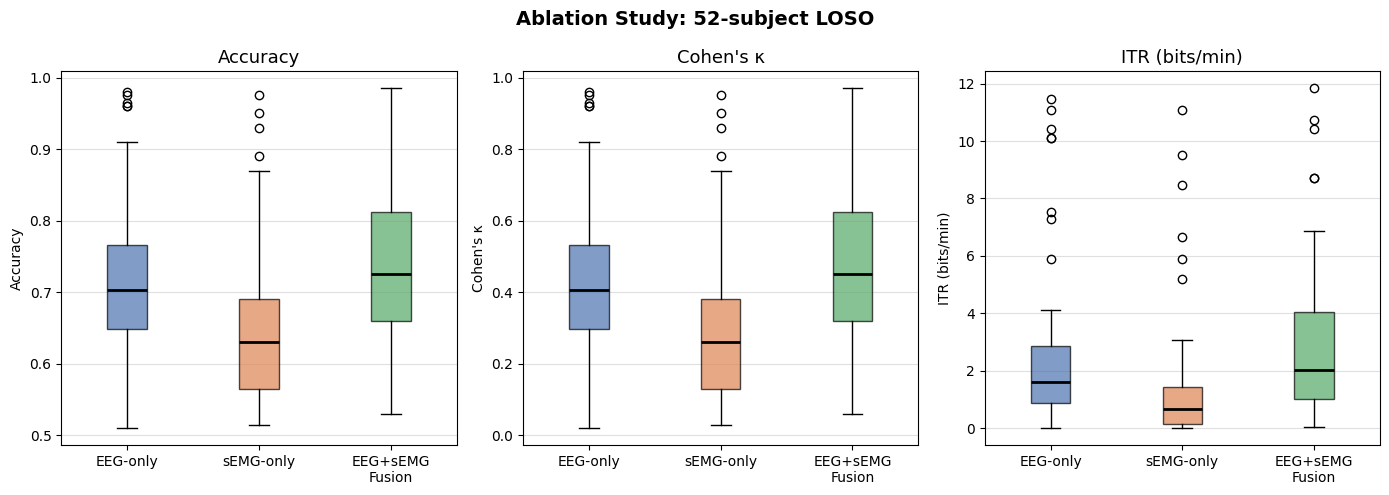

저장: ablation_boxplot.png


In [9]:
# ── 셀 7: 시각화 ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUT = f'{DRIVE_ROOT}/results/ablation'

df = pd.read_csv(f'{OUT}/ablation_results.csv')
conditions = ['eeg_only', 'emg_only', 'fusion']
labels = ['EEG-only', 'sEMG-only', 'EEG+sEMG\nFusion']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics   = [('acc', 'Accuracy'), ('kappa', "Cohen's \u03ba"), ('itr', 'ITR (bits/min)')]

for ax, (m, title) in zip(axes, metrics):
    vals = [df[f'{m}_{c}'].values for c in conditions]
    bp = ax.boxplot(vals, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Ablation Study: 52-subject LOSO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/ablation_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: ablation_boxplot.png')
